# Stage 08: Scoring Pipeline

Score holdout, new data, or production data using saved encoder and model

In [1]:
config_path = 'config/car_coll/v1'
score_name = 'holdout'

In [2]:
# Parameters
config_path = "config/car_liab/v1"


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import yaml, os, sys, joblib
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from preprocessing import condition_data
print('######## STAGE 08: SCORING ########')
project_root = setup_notebook_environment()

######## STAGE 08: SCORING ########


In [4]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

with open(f'{config_path}/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
output_base = cfg['machines'][pc_id]['paths']['output_path']
score_cfg = cfg['scoring'][score_name]
print(f'Scoring: {score_name}')
print(f'Has target: {score_cfg.get("has_target", False)}')

Scoring: holdout
Has target: True


In [5]:
# Load data based on source type
print(f'\n* Loading data...')

if score_cfg['source'] == 'master':
    # Holdout scoring: Load master + aux, join, filter by fold
    print(f"  Source: master file with fold filter")
    
    # Load aux data (has fold column)
    aux_path = cfg['machines'][pc_id]['paths']['aux_data_path']
    aux_file = cfg['data']['aux_file']
    fold_col = cfg['data']['fold_column']
    join_key = cfg['data']['join_key']
    
    print(f"  Loading aux: {aux_path}/{aux_file}")
    aux_data = pd.read_parquet(f'{aux_path}/{aux_file}')
    
    # Filter aux to requested folds
    needed_folds = score_cfg['folds']
    aux_filtered = aux_data[aux_data[fold_col].isin(needed_folds)]
    print(f"  Filtered aux to folds {needed_folds}: {aux_filtered.shape[0]:,} rows")
    
    # Load master data
    master_path = cfg['machines'][pc_id]['paths']['master_data_path']
    master_file = cfg['data']['master_file']
    print(f"  Loading master: {master_path}/{master_file}")
    
    # Load all columns from master
    master_data = pd.read_parquet(f'{master_path}/{master_file}')
    print(f"  Loaded master: {master_data.shape}")
    
    # Join master with aux (to get fold)
    # Join master with aux (fold + target if needed)
    aux_cols = [join_key, fold_col]
    if score_cfg.get('has_target', False):
        target = cfg['experiment']['target']
        if target in aux_filtered.columns:
            aux_cols.append(target)
            print(f'  Including target from aux: {target}')
    df = master_data.merge(aux_filtered[aux_cols], on=join_key, how='inner')
    print(f"  After join: {df.shape}")
    print(f"  Fold distribution: {df[fold_col].value_counts().sort_index().to_dict()}")
    
elif score_cfg['source'] == 'file':
    # New data scoring: Load file directly
    print(f"  Source: file (new data)")
    data_path = score_cfg.get('data_dir', cfg['machines'][pc_id]['paths']['master_data_path'])
    file_name = score_cfg['file']
    print(f"  Loading: {data_path}/{file_name}")
    df = pd.read_parquet(f'{data_path}/{file_name}')
    print(f"  Loaded: {df.shape}")
    
else:
    raise ValueError(f"Unknown source type: {score_cfg['source']}")

print(f'\n* Data loaded: {df.shape}')

# Save target and exposure for metrics (if available)
target_values = None
exposure_values = None
if score_cfg.get('has_target', False):
    target = cfg['experiment']['target']
    exposure = cfg['experiment']['exposure']
    if target in df.columns:
        target_values = df[target].copy()
        print(f'  Saved target for metrics: {target}')
    if exposure in df.columns:
        exposure_values = df[exposure].copy()
        print(f'  Saved exposure for metrics: {exposure}')


* Loading data...
  Source: master file with fold filter
  Loading aux: /Users/Mach/dev/aps/data/2026_Dmodel_data/car_with_dep_factor_fold.parquet


  Filtered aux to folds [8, 9, 10]: 8,112,962 rows
  Loading master: /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet


  Loaded master: (22705842, 406)
  Including target from aux: pp_bi


  After join: (8112962, 408)
  Fold distribution: {8: 2707146, 9: 2706978, 10: 2698838}

* Data loaded: (8112962, 408)
  Saved target for metrics: pp_bi
  Saved exposure for metrics: ee_bi_imps


In [6]:
# Preserve target and exposure before conditioning
print(f'\n* Conditioning...')
target = cfg['experiment']['target']
exposure = cfg['experiment']['exposure']

# Save target/exposure if they exist
target_data = None
exposure_data = None
if target in df.columns:
    target_data = df[target].copy()
    print(f'  Preserved target: {target}')
if exposure in df.columns:
    exposure_data = df[exposure].copy()
    print(f'  Preserved exposure: {exposure}')

# Apply conditioning (this may drop target/exposure)
df = condition_data(df, cfg)
print(f'  After conditioning: {df.shape}')

# Restore target/exposure if they were present
if target_data is not None:
    df[target] = target_data
    print(f'  Restored target: {target}')
if exposure_data is not None:
    df[exposure] = exposure_data
    print(f'  Restored exposure: {exposure}')

print(f'  Final shape: {df.shape}')


* Conditioning...
  Preserved target: pp_bi
  Preserved exposure: ee_bi_imps


  After conditioning: (8112962, 408)
  Restored target: pp_bi
  Restored exposure: ee_bi_imps
  Final shape: (8112962, 408)


In [7]:
# Drop auxiliary columns before encoding
print(f'\n* Dropping auxiliary columns...')
aux_cols = ['fold', 'vin_date', 'VIN_Date', 'vindate']  # Common aux columns
cols_to_drop = [c for c in aux_cols if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f'  Dropped: {cols_to_drop}')
else:
    print(f'  No aux columns to drop')
print(f'  Data shape: {df.shape}')


* Dropping auxiliary columns...
  Dropped: ['fold', 'vin_date']
  Data shape: (8112962, 406)


In [8]:
# Load encoders and encoding summary
print(f'\n* Loading encoder...')
import joblib
with open(f'{output_base}/models/04c_encoders.pkl', 'rb') as f:
    encoders = joblib.load(f)

encoding_summary = pd.read_csv(f'{output_base}/results/04c_encoding_summary.csv')
print(f'  Loaded {len(encoders)} encoders and encoding summary')

# Encode features
print(f'\n* Encoding...')
from feature_encoder import apply_saved_encoders
df_encoded = apply_saved_encoders(df, encoders, encoding_summary)
print(f'  Encoded: {df_encoded.shape}')

# Compare with training columns and fix mismatch
X_train_ref = pd.read_parquet(f'{output_base}/data/04c_train_encoded.parquet')
train_cols = set(X_train_ref.columns)
encoded_cols = set(df_encoded.columns)
extra_in_encoded = encoded_cols - train_cols
missing_in_encoded = train_cols - encoded_cols
if extra_in_encoded:
    print(f'  ⚠ EXTRA columns: {extra_in_encoded}')
    df_encoded = df_encoded.drop(columns=list(extra_in_encoded))
    print(f'  Dropped extra. New shape: {df_encoded.shape}')
if missing_in_encoded:
    print(f'  ⚠ MISSING columns: {missing_in_encoded}')


* Loading encoder...
  Loaded 30 encoders and encoding summary

* Encoding...


[OK] Applied saved encoders: (8112962, 199)
  Encoded: (8112962, 199)


  ⚠ EXTRA columns: {'vc_vehicle_immobilizer_raw'}
  Dropped extra. New shape: (8112962, 198)


In [9]:
# Load model
print(f'\n* Loading model...')
model_file = f'{output_base}/models/05c_model.json'
model = xgb.XGBRegressor()
model.load_model(model_file)
print(f'  Model loaded: {model_file}')

# Validate features match
from model_validation import validate_features_match
validate_features_match(model, df_encoded, 'df_encoded')

# Predict
print(f'\n* Predicting...')
df['prediction'] = model.predict(df_encoded)
print(f'  Done')

# Validate predictions
from model_validation import validate_predictions
validate_predictions(df['prediction'].values, df)


* Loading model...
  Model loaded: output/car_liab/v1/models/05c_model.json

* Feature Validation:
  Model expects: 198 features
  df_encoded has: 198 features
  ⚠ Model has no feature names stored (can't verify names)
  ✓ Validation passed


* Predicting...


  Done

* Prediction Validation:
  Shape: (8112962,)
  Min: 49.94
  Max: 1540.92
  Mean: 198.16
  Median: 141.50
  ✓ Predictions valid



/var/folders/v0/9dsqbvc54xb7m5hl9q0typp80000gn/T/ipykernel_75631/1507284456.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['prediction'] = model.predict(df_encoded)


True

In [10]:
print(f'\n* Saving...')
output_dir = f'{output_base}/scoring/{score_name}'
os.makedirs(output_dir, exist_ok=True)
df.to_parquet(f'{output_dir}/predictions.parquet')
print(f'  Saved: scoring/{score_name}/predictions.parquet')


* Saving...


  Saved: scoring/holdout/predictions.parquet


In [11]:
# Calculate metrics (if target available)
if score_cfg.get('has_target', False):
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np
    import pandas as pd
    
    if target_values is None or exposure_values is None:
        print('\n⚠ Warning: Target/exposure not available for metrics')
    else:
        print(f'\n* Calculating metrics...')
        
        # Create aligned series and check for NaN
        metrics_df = pd.DataFrame({
            'target': target_values,
            'prediction': df['prediction'],
            'exposure': exposure_values
        })
        
        print(f'  Total rows: {len(metrics_df):,}')
        
        # Check for NaN
        nan_mask = metrics_df.isna().any(axis=1)
        n_nan = nan_mask.sum()
        if n_nan > 0:
            print(f'  ⚠ Found {n_nan:,} rows with NaN values')
            print(f'    NaN in target: {metrics_df["target"].isna().sum():,}')
            print(f'    NaN in prediction: {metrics_df["prediction"].isna().sum():,}')
            print(f'    NaN in exposure: {metrics_df["exposure"].isna().sum():,}')
            print(f'  Filtering out NaN rows...')
            metrics_df = metrics_df[~nan_mask]
        
        print(f'  Valid rows for metrics: {len(metrics_df):,}')
        
        # Calculate metrics on clean data
        mae = mean_absolute_error(
            metrics_df['target'],
            metrics_df['prediction'],
            sample_weight=metrics_df['exposure']
        )
        rmse = np.sqrt(mean_squared_error(
            metrics_df['target'],
            metrics_df['prediction'],
            sample_weight=metrics_df['exposure']
        ))
        
        print(f'  MAE: {mae:.4f}')
        print(f'  RMSE: {rmse:.4f}')
        
        # Save metrics
        metrics = {
            'score_name': score_name,
            'mae': float(mae),
            'rmse': float(rmse),
            'n_rows': len(metrics_df),
            'n_rows_with_nan': int(n_nan) if n_nan > 0 else 0
        }
        
        with open(f'{output_dir}/metrics.yaml', 'w') as f:
            yaml.dump(metrics, f)
        print(f'  Metrics saved to {output_dir}/metrics.yaml')
else:
    print('\n* No target available (has_target=False)')


* Calculating metrics...
  Total rows: 8,112,962
  ⚠ Found 428,373 rows with NaN values
    NaN in target: 428,373
    NaN in prediction: 0
    NaN in exposure: 0
  Filtering out NaN rows...


  Valid rows for metrics: 7,684,589
  MAE: 279.0943
  RMSE: 6996.4565
  Metrics saved to output/car_liab/v1/scoring/holdout/metrics.yaml



* Creating lift chart...


  Creating chart for 7,684,589 rows...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 7,684,589 rows...
  [STEP 2] Done in 0.072s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.7s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.001s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.053s
  [STEP 5] Aggregating by decile...


  [STEP 5] Done in 0.231s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 1.0s
  Saved: output/car_liab/v1/scoring/holdout/lift_chart.png


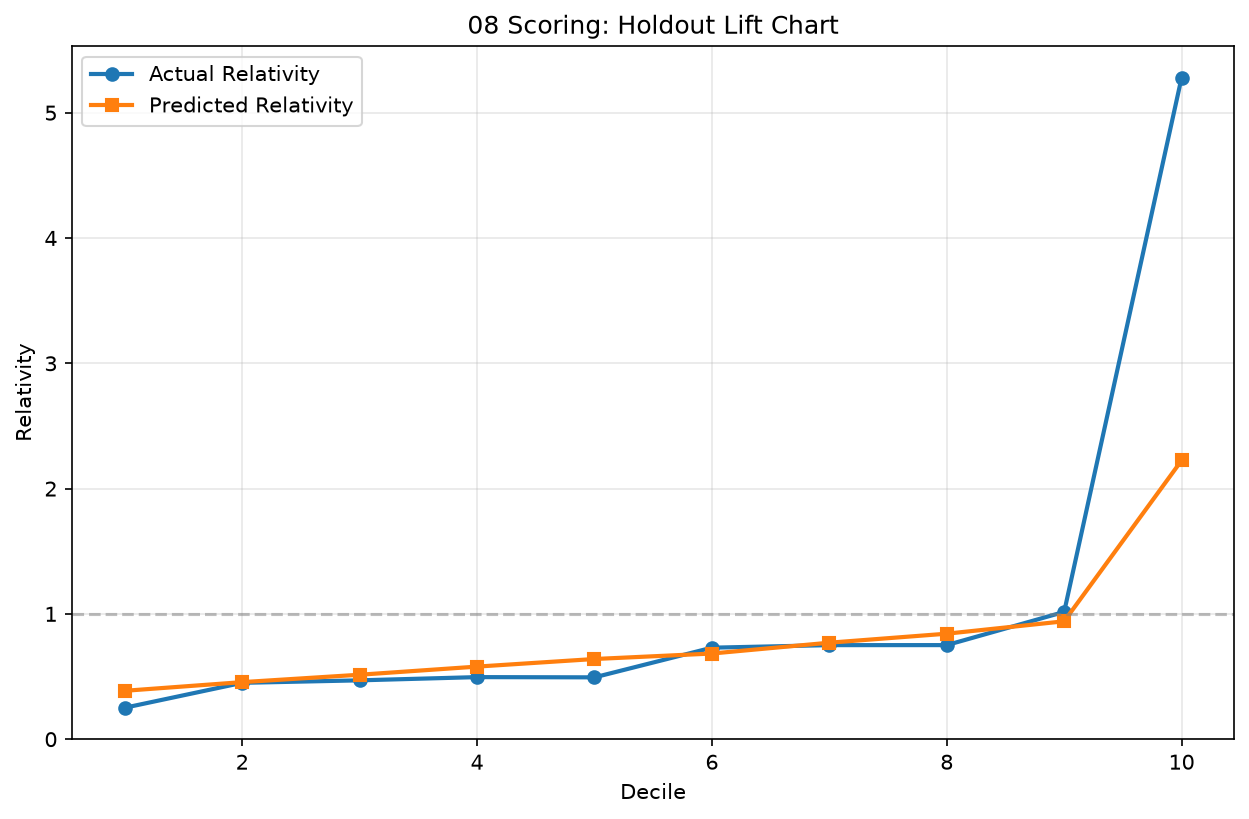


Decile summary:
 decile        act       pred  act_rel  pred_rel
      1  44.823315  68.988405 0.250924  0.386202
      2  80.334849  81.330139 0.449720  0.455292
      3  83.892512  91.888504 0.469636  0.514398
      4  88.492638 103.476158 0.495388  0.579267
      5  88.157228 114.303914 0.493510  0.639881
      6 130.447227 122.113470 0.730253  0.683600
      7 134.082750 137.575802 0.750605  0.770159
      8 134.127323 150.399966 0.750854  0.841950
      9 181.447316 168.084251 1.015755  0.940948
     10 943.016873 397.350564 5.279076  2.224397


In [12]:
# Create lift chart (if target available)
if score_cfg.get('has_target', False) and target_values is not None:
    import matplotlib.pyplot as plt
    from lift_chart_fast import create_lift_chart
    from IPython.display import Image, display
    
    print(f'\n* Creating lift chart...')
    
    # Prepare dataframe for lift chart
    target = cfg['experiment']['target']
    exposure = cfg['experiment']['exposure']
    
    # Create temp dataframe with required columns
    lift_df = df[['prediction']].copy()
    lift_df['pred'] = df['prediction']
    lift_df['incurred_act'] = target_values.values
    lift_df['incurred_pred'] = df['prediction'].values
    lift_df['denom'] = 1  # Pure premium target, don't divide by exposure again
    lift_df[exposure] = exposure_values.values  # For weighted deciles
    
    # Remove NaN rows
    lift_df = lift_df.dropna()
    
    print(f'  Creating chart for {len(lift_df):,} rows...')
    
    fig, table = create_lift_chart(
        lift_df,
        exposure,
        bins=10,
        title=f'08 Scoring: {score_name.title()} Lift Chart'
    )
    
    chart_file = f'{output_dir}/lift_chart.png'
    fig.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {chart_file}')
    
    display(Image(chart_file))
    print(f'\nDecile summary:')
    print(table[['decile', 'act', 'pred', 'act_rel', 'pred_rel']].to_string(index=False))
else:
    print(f'\n* Skipping lift chart (no target available)')

In [13]:
# Calculate actuarial metrics (if target available)
if score_cfg.get('has_target', False) and target_values is not None:
    from hpo_metrics import compute_fit_quality, compute_model_power
    
    print(f'\n* Calculating actuarial metrics...')
    
    # Use clean data (no NaN)
    if 'metrics_df' in locals():
        clean_target = metrics_df['target'].values
        clean_pred = metrics_df['prediction'].values
        clean_exposure = metrics_df['exposure'].values
    else:
        # Fallback if metrics_df not created
        mask = ~(pd.isna(target_values) | pd.isna(df['prediction']) | pd.isna(exposure_values))
        clean_target = target_values[mask].values
        clean_pred = df.loc[mask, 'prediction'].values
        clean_exposure = exposure_values[mask].values
    
    fit_quality = compute_fit_quality(clean_target, clean_pred, clean_exposure)
    model_power = compute_model_power(clean_target, clean_pred, clean_exposure)
    
    print(f'\n* Actuarial Metrics ({score_name}):')
    print(f'    Fit Quality:  {fit_quality:.4f}')
    print(f'    Model Power:  {model_power:.4f}')
    
    # Add to saved metrics if it exists
    if 'metrics' in locals():
        metrics['fit_quality'] = float(fit_quality)
        metrics['model_power'] = float(model_power)
        with open(f'{output_dir}/metrics.yaml', 'w') as f:
            yaml.dump(metrics, f)
        print(f'  Updated metrics.yaml')
else:
    print(f'\n* Skipping actuarial metrics (no target available)')


* Calculating actuarial metrics...



* Actuarial Metrics (holdout):
    Fit Quality:  0.8312
    Model Power:  0.3399
  Updated metrics.yaml
